# Split Datasets For BERT - Stage 1

Split dataset to Train/Validation/Test sets for BERT

## A. Overview

ration 80:10:10


In [7]:
from pathlib import Path
import csv
import os
import random

from sklearn.model_selection import train_test_split
import pandas as pd
import matplotlib.pyplot as plt

import configuration
from src import data_utils, setup

random.seed(setup.RANDOM_SEED)

In [8]:
dataset_path = Path("..") / "data"
# disaster_path = dataset_path / "disaster"
# extended_filepath = dataset_path / "extended"
splitted_filepath = dataset_path / "splitted"
stage_filepath = splitted_filepath / "stage_1"

strategies = ["crossed", "isolated"]

## B. Load Datasets

In [9]:
def load_bert_datasets(strategy: str):
    df = pd.read_csv(stage_filepath / strategy / "bert_sets.csv")

    df_disaster = df[df["subset"] == "disaster"]
    df_humanitarian = df_disaster[~df_disaster["humanitarian_label"].isna()]
    df_weather = df[df["subset"] == "weather"]
    df_out_topic = df[df["subset"] == "out_topic"]

    print(f"Base disaster dataset size: {df_disaster.groupby('informative').size()}")
    print(
        f"Base humanitarian dataset size: {df_humanitarian.groupby('informative').size()}"
    )
    print(f"Base weather dataset size: {len(df_weather)}")
    print(f"Base out-topic dataset size: {len(df_out_topic)}")
    return df_disaster, df_weather, df_out_topic

## C. Split Experiment Sets

In [10]:
def create_experiment_datasets(
    df_disaster_original,
    df_weather_original,
    df_out_topic_original,
    n_weather,
    n_out_topic,
):
    print(f"Weather: {n_weather}, Out-topic : {n_out_topic}")

    df_experiment_weather = df_weather_original.sample(
        n=n_weather, random_state=setup.RANDOM_SEED
    )
    print(f"Weather samples: {len(df_weather_original)}")
    print(f"Weather experiment samples: {len(df_experiment_weather)}")

    df_experiment_out_topic = df_out_topic_original.sample(
        n=n_out_topic, random_state=setup.RANDOM_SEED
    )
    print(f"Out-topic samples: {len(df_out_topic_original)}")
    print(f"Out-topic experiment samples: {len(df_experiment_out_topic)}")

    df_experiment = (
        pd.concat(
            [df_disaster_original, df_experiment_weather, df_experiment_out_topic],
            ignore_index=True,
        )
        .sample(frac=data_utils.DATA_FRACTION, random_state=setup.RANDOM_SEED)
        .reset_index(drop=True)
    )

    return df_experiment


def split_then_export_datasets(
    df, validation_sizes=0.1, test_sizes=0.1, save_path: Path = None
):
    df_train, df_validation = train_test_split(
        df,
        test_size=validation_sizes + test_sizes,
        random_state=setup.RANDOM_SEED,
        stratify=df["informative"],
    )
    df_validation, df_test = train_test_split(
        df_validation,
        test_size=test_sizes / (validation_sizes + test_sizes),
        random_state=setup.RANDOM_SEED,
        stratify=df_validation["informative"],
    )
    save_path.mkdir(parents=True, exist_ok=True)
    df_train.to_csv(save_path / "train.csv", index=False, quoting=csv.QUOTE_ALL)

    df_validation.to_csv(
        save_path / "validation.csv",
        index=False,
        quoting=csv.QUOTE_ALL,
    )

    df_test.to_csv(save_path / "test.csv", index=False, quoting=csv.QUOTE_ALL)

    print(len(df_train))
    print(len(df_validation))
    print(len(df_test))

    # ration between train, validation, and test sets
    total = len(df_train) + len(df_validation) + len(df_test)
    print(f"Train: {len(df_train) / total:.2%}")
    print(f"Validation: {len(df_validation) / total:.2%}")
    print(f"Test: {len(df_test) / total:.2%}")

    dist = pd.DataFrame(
        {
            "Train": df_train["informative"].value_counts(normalize=True).sort_index(),
            "Validation": df_validation["informative"]
            .value_counts(normalize=True)
            .sort_index(),
            "Test": df_test["informative"].value_counts(normalize=True).sort_index(),
        }
    ).fillna(0)

    subset_dist = pd.DataFrame(
        {
            "Train": df_train[["informative", "subset"]]
            .value_counts(normalize=True)
            .sort_index(),
            "Validation": df_validation[["informative", "subset"]]
            .value_counts(normalize=True)
            .sort_index(),
            "Test": df_test[["informative", "subset"]]
            .value_counts(normalize=True)
            .sort_index(),
        }
    ).fillna(0)

    return dist, subset_dist

## D. Split multiple sets for BERT

In [11]:
def split_multiple_experiments(
    df_disaster,
    df_weather,
    df_out_topic,
    strategy: str,
    n_weather: int,
    n_out_topic: int,
):
    df_experiment = create_experiment_datasets(
        df_disaster,
        df_weather,
        df_out_topic,
        n_weather,
        n_out_topic,
    )

    print(
        f"Experiment Dataset distribution:\n{df_experiment['informative'].value_counts(normalize=True)}"
    )
    print("-" * 50)
    print(f"Experiment Dataset size: {len(df_experiment)}")

    save_path = (
        stage_filepath
        / strategy
        / "BERT"
        / data_utils.get_experiment_ratios_path(n_weather, n_out_topic)
    )

    dist, subset_dist = split_then_export_datasets(df_experiment, save_path=save_path)

    ax = dist.T.plot(kind="bar", figsize=(8, 5), rot=0)
    ax.set_xlabel("Set")
    ax.set_ylabel("Proportion")
    ax.set_title("Distribution of informative and non-informative tweets")
    ax.legend(title="informative")
    plt.tight_layout()
    plt.show()

    ax = subset_dist.T.plot(kind="bar", figsize=(8, 5), rot=0)
    ax.set_xlabel("Set")
    ax.set_ylabel("Proportion")
    ax.set_title("Distribution of tweets by subsets")
    ax.legend(title="Subset")
    plt.tight_layout()
    plt.show()

## E. Do the splits

/var/folders/yh/9qq7z2f14f14bdj_1k2673700000gn/T/ipykernel_51902/866712793.py:2: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(stage_filepath / strategy / "bert_sets.csv")


Base disaster dataset size: informative
False    5490
True     8886
dtype: int64
Base humanitarian dataset size: informative
False    2524
True     5943
dtype: int64
Base weather dataset size: 2578
Base out-topic dataset size: 169652
Weather: 1, Out-topic : 125222
Weather samples: 2578
Weather experiment samples: 1
Out-topic samples: 169652
Out-topic experiment samples: 125222
Experiment Dataset distribution:
informative
False    0.936346
True     0.063654
Name: proportion, dtype: float64
--------------------------------------------------
Experiment Dataset size: 139599
111679
13960
13960
Train: 80.00%
Validation: 10.00%
Test: 10.00%


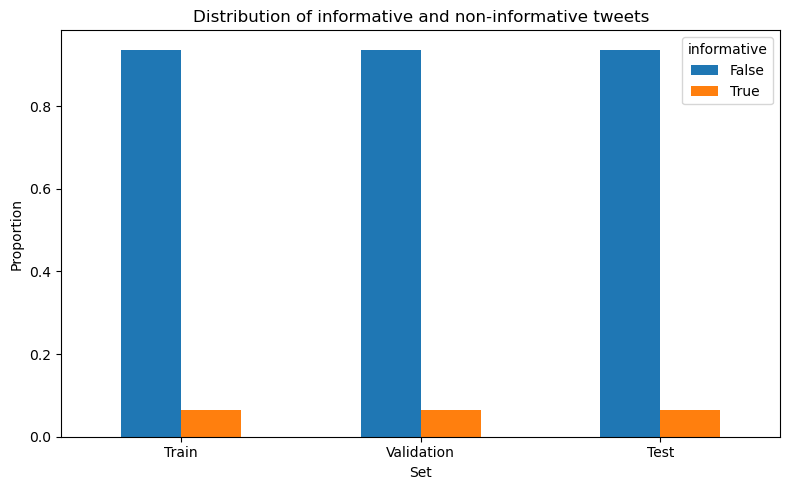

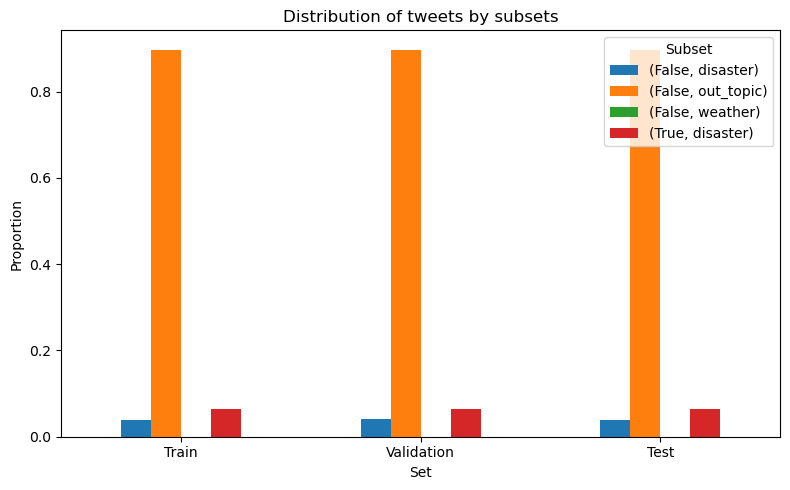

Weather: 1, Out-topic : 169652
Weather samples: 2578
Weather experiment samples: 1
Out-topic samples: 169652
Out-topic experiment samples: 169652
Experiment Dataset distribution:
informative
False    0.951714
True     0.048286
Name: proportion, dtype: float64
--------------------------------------------------
Experiment Dataset size: 184029
147223
18403
18403
Train: 80.00%
Validation: 10.00%
Test: 10.00%


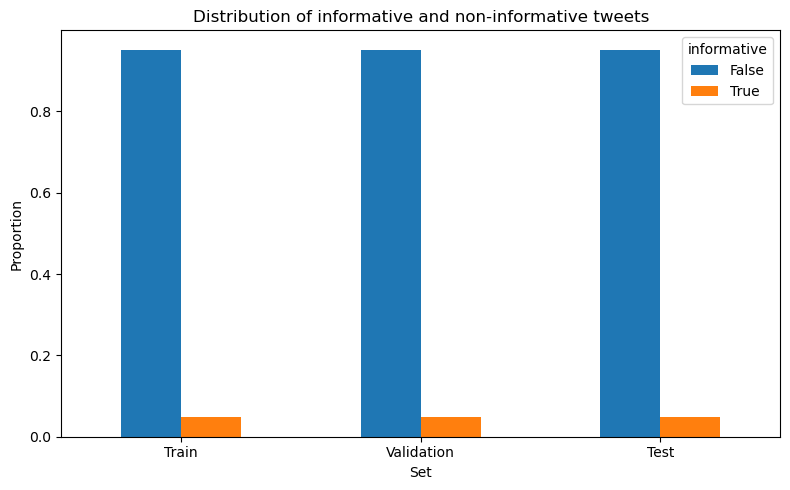

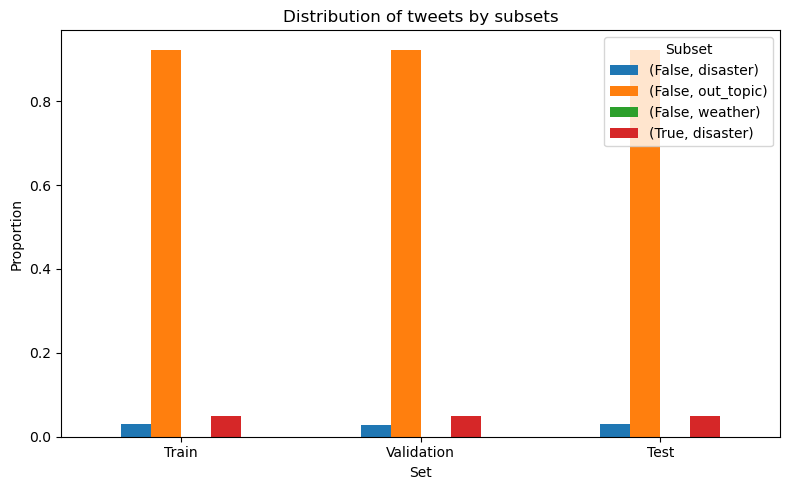

In [13]:
strategy = "crossed"
df_crossed_disaster, df_crossed_weather, df_crossed_out_topic = load_bert_datasets(
    strategy=strategy
)
for n_weather, n_out_topic in data_utils.BERT_CROSSED_EXPERIMENT_N:
    split_multiple_experiments(
        df_crossed_disaster,
        df_crossed_weather,
        df_crossed_out_topic,
        strategy=strategy,
        n_weather=n_weather,
        n_out_topic=n_out_topic,
    )

Base disaster dataset size: informative
False    29774
True     29794
dtype: int64
Base humanitarian dataset size: Series([], dtype: int64)
Base weather dataset size: 12890
Base out-topic dataset size: 553216
Weather: 12890, Out-topic : 403777
Weather samples: 12890
Weather experiment samples: 12890
Out-topic samples: 553216
Out-topic experiment samples: 403777
Experiment Dataset distribution:
informative
False    0.937438
True     0.062562
Name: proportion, dtype: float64
--------------------------------------------------
Experiment Dataset size: 476235
380988
47623
47624
Train: 80.00%
Validation: 10.00%
Test: 10.00%


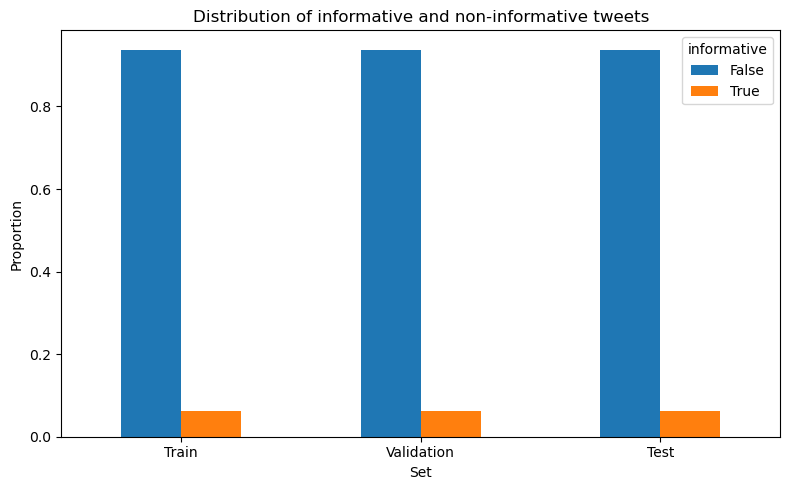

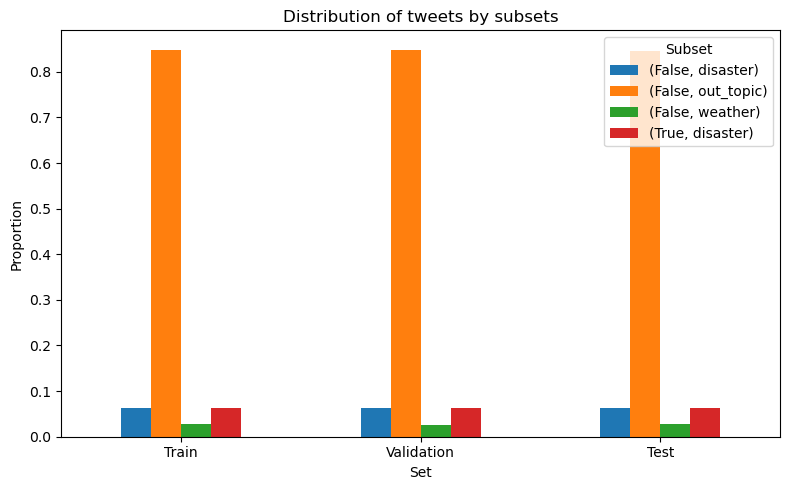

Weather: 12890, Out-topic : 552597
Weather samples: 12890
Weather experiment samples: 12890
Out-topic samples: 553216
Out-topic experiment samples: 552597
Experiment Dataset distribution:
informative
False    0.952334
True     0.047666
Name: proportion, dtype: float64
--------------------------------------------------
Experiment Dataset size: 625055
500044
62505
62506
Train: 80.00%
Validation: 10.00%
Test: 10.00%


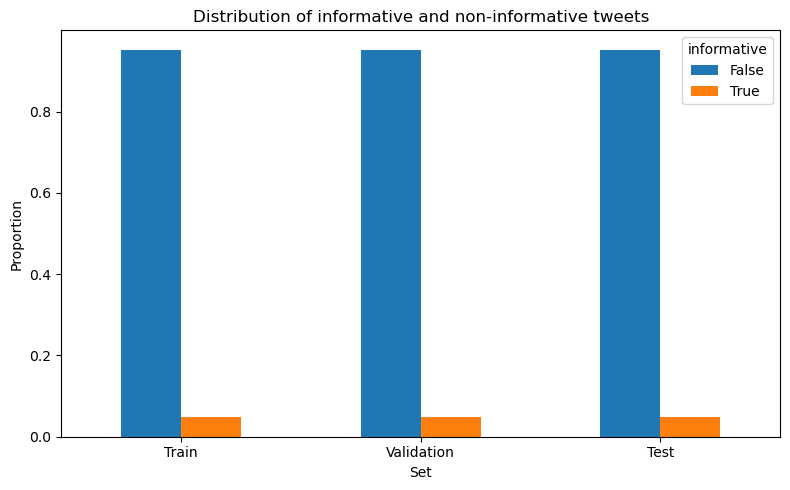

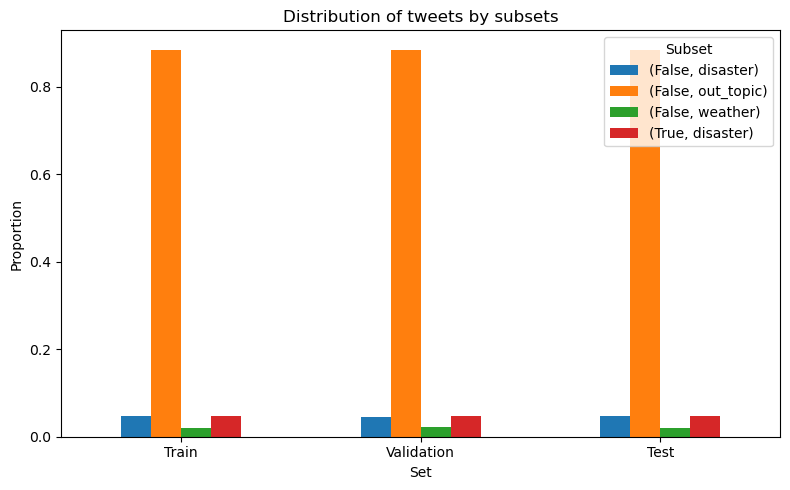

In [15]:
strategy = "isolated"
df_iso_disaster, df_iso_weather, df_iso_out_topic = load_bert_datasets(strategy=strategy)

for n_weather, n_out_topic in data_utils.BERT_ISO_EXPERIMENT_N:
    split_multiple_experiments(
        df_iso_disaster,
        df_iso_weather,
        df_iso_out_topic,
        strategy=strategy,
        n_weather=n_weather,
        n_out_topic=n_out_topic,
    )